# Feature Engineering - BoardGames Dataset

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from kneed import KneeLocator
from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

In [2]:
df = pd.read_csv("../data/processed/boardgames_clean.csv")

In [3]:
df.shape

(22251, 319)

In [4]:
df.head()

,id,name,average_rating,yearpublished,minplayers,maxplayers,playingtime,minplaytime,maxplaytime,minage,...,mech_up_and_deliver,mech_use_cards,mech_variable_phase_order,mech_variable_player_powers,mech_variable_set,mech_victory_points_as_a_resource,mech_voting,mech_worker_placement,mech_worker_placement_with_dice_workers,mech_zone_of_control
0,224517,Brass: Birmingham,8.57,2018,2,4,120,60,120,14,...,0.0,0.281332,0.0,0.000000,0.210748,0.0,0.0,0.00000,0.0,0.0
1,342942,Ark Nova,8.54,2021,1,4,150,90,150,14,...,0.0,0.000000,0.0,0.162515,0.239000,0.0,0.0,0.00000,0.0,0.0
2,161936,Pandemic Legacy: Season 1,8.50,2015,2,4,60,60,60,13,...,0.0,0.000000,0.0,0.210911,0.000000,0.0,0.0,0.00000,0.0,0.0
3,174430,Gloomhaven,8.54,2017,1,4,120,60,120,14,...,0.0,0.218552,0.0,0.111325,0.000000,0.0,0.0,0.00000,0.0,0.0
4,316554,Dune: Imperium,8.41,2020,1,4,120,60,120,14,...,0.0,0.262149,0.0,0.133533,0.000000,0.0,0.0,0.18131,0.0,0.0


In [5]:
print("Column headers:", list(df))

Column headers: ['id', 'name', 'average_rating', 'yearpublished', 'minplayers', 'maxplayers', 'playingtime', 'minplaytime', 'maxplaytime', 'minage', 'averageweight', 'users_rated', 'owned', 'wishing', 'rank', 'cat_play', 'cat_abstract_strategy', 'cat_action_dexterity', 'cat_adventure', 'cat_age_of_reason', 'cat_american_civil_war', 'cat_american_indian_wars', 'cat_american_revolutionary_war', 'cat_american_west', 'cat_ancient', 'cat_animals', 'cat_arabian', 'cat_aviation_flight', 'cat_based', 'cat_bluffing', 'cat_book', 'cat_card_game', 'cat_children', 'cat_city_building', 'cat_civil_war', 'cat_civilization', 'cat_collectible_components', 'cat_comic_book_strip', 'cat_deduction', 'cat_dice', 'cat_economic', 'cat_educational', 'cat_electronic', 'cat_environmental', 'cat_expansion_for_base', 'cat_exploration', 'cat_fan_expansion', 'cat_fantasy', 'cat_farming', 'cat_fighting', 'cat_game', 'cat_game_system', 'cat_horror', 'cat_humor', 'cat_industry_manufacturing', 'cat_korean_war', 'cat_maf

## Preparing the dataset

Although the dataset was cleaned and functional, not all the rows have values that we can use, neither we are going to use all the columns

In [6]:
#Check how many rows with 0 are in averageweight and minage columns. 
(df.iloc[:,9:11]==0).sum().sum()

np.int64(1141)

In [7]:
# 0 is not a valid result in those columns. We are going to replace them with the median
# First we change them to NaN in order to use fillna to use the median

df["averageweight"] = df["averageweight"].replace(0, np.nan)
df["minage"] = df["minage"].replace(0, np.nan)

df["averageweight"] = df["averageweight"].fillna(df["averageweight"].median())
df["minage"] = df["minage"].fillna(df["minage"].median())

### Logaritmic transformation

Check if it's needed

In [8]:
print(df["users_rated"].skew())
print(df["owned"].skew())
print(df["wishing"].skew())

11.980863085590093
12.16709686557988
9.280722110371963


<Axes: xlabel='users_rated', ylabel='Count'>

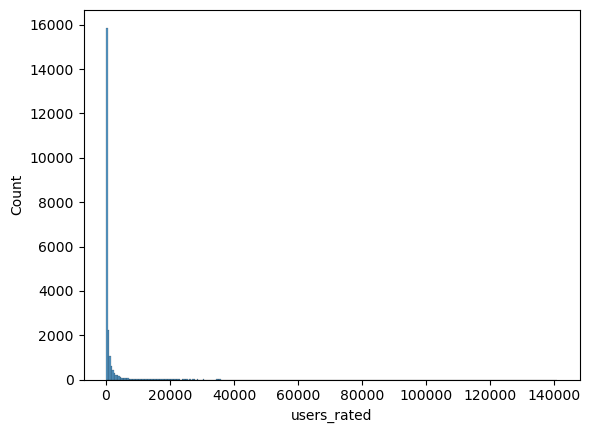

In [9]:
sns.histplot(df["users_rated"])

High skewness means we can apply the logaritmic transformation

In [10]:
new_cols = pd.DataFrame({
    "log_users_rated": np.log1p(df["users_rated"]),
    "log_owned": np.log1p(df["owned"]),
    "log_wishing": np.log1p(df["wishing"])
}, index=df.index)

df = pd.concat([df, new_cols], axis=1)

In [11]:
df = df.drop(columns=["users_rated", "owned", "wishing"])
print("Column headers:", list(df))

Column headers: ['id', 'name', 'average_rating', 'yearpublished', 'minplayers', 'maxplayers', 'playingtime', 'minplaytime', 'maxplaytime', 'minage', 'averageweight', 'rank', 'cat_play', 'cat_abstract_strategy', 'cat_action_dexterity', 'cat_adventure', 'cat_age_of_reason', 'cat_american_civil_war', 'cat_american_indian_wars', 'cat_american_revolutionary_war', 'cat_american_west', 'cat_ancient', 'cat_animals', 'cat_arabian', 'cat_aviation_flight', 'cat_based', 'cat_bluffing', 'cat_book', 'cat_card_game', 'cat_children', 'cat_city_building', 'cat_civil_war', 'cat_civilization', 'cat_collectible_components', 'cat_comic_book_strip', 'cat_deduction', 'cat_dice', 'cat_economic', 'cat_educational', 'cat_electronic', 'cat_environmental', 'cat_expansion_for_base', 'cat_exploration', 'cat_fan_expansion', 'cat_fantasy', 'cat_farming', 'cat_fighting', 'cat_game', 'cat_game_system', 'cat_horror', 'cat_humor', 'cat_industry_manufacturing', 'cat_korean_war', 'cat_mafia', 'cat_math', 'cat_mature_adult'

### New features

We will combine certain columns to have the information more compacted

In [12]:
new_cols2 = pd.DataFrame({"playtime_mean": (df["minplaytime"] + df["maxplaytime"]) / 2}, index=df.index)

df = pd.concat([df, new_cols2], axis=1)

In [13]:
df = df.drop(columns=["minplaytime", "maxplaytime", "playingtime"])         # in the correlation matrix we saw that maxplaytime == playingtime
print("Column headers:", list(df))

Column headers: ['id', 'name', 'average_rating', 'yearpublished', 'minplayers', 'maxplayers', 'minage', 'averageweight', 'rank', 'cat_play', 'cat_abstract_strategy', 'cat_action_dexterity', 'cat_adventure', 'cat_age_of_reason', 'cat_american_civil_war', 'cat_american_indian_wars', 'cat_american_revolutionary_war', 'cat_american_west', 'cat_ancient', 'cat_animals', 'cat_arabian', 'cat_aviation_flight', 'cat_based', 'cat_bluffing', 'cat_book', 'cat_card_game', 'cat_children', 'cat_city_building', 'cat_civil_war', 'cat_civilization', 'cat_collectible_components', 'cat_comic_book_strip', 'cat_deduction', 'cat_dice', 'cat_economic', 'cat_educational', 'cat_electronic', 'cat_environmental', 'cat_expansion_for_base', 'cat_exploration', 'cat_fan_expansion', 'cat_fantasy', 'cat_farming', 'cat_fighting', 'cat_game', 'cat_game_system', 'cat_horror', 'cat_humor', 'cat_industry_manufacturing', 'cat_korean_war', 'cat_mafia', 'cat_math', 'cat_mature_adult', 'cat_maze', 'cat_medical', 'cat_medieval', 

## Categories

Manage all the columns of the categories

In [14]:
cat_cols = [c for c in df.columns if c.startswith("cat_")]
mech_cols = [c for c in df.columns if c.startswith("mech_")]

X_cat = df[cat_cols]
X_mech = df[mech_cols]

In [15]:
print(X_cat.shape)
print(X_mech.shape)

(22251, 89)
(22251, 215)


#### We will use TruncatedSVD and KMeans to create some "type" of games

#### TruncatedSVD vs PCA (Principal Component Analysis)

Because the data comes from TF-IDF, we have a sparse matrix, so Truncated SVC could be better



#### Categories

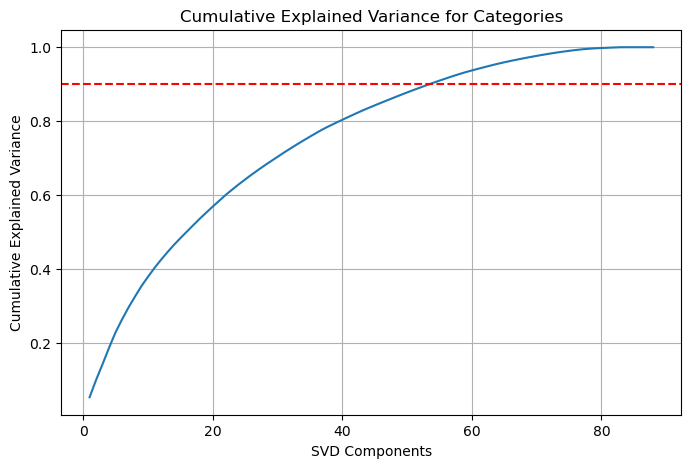

Optimal number of svd components: 54


In [16]:
# Determine optimal number of components (Cumulative Explained Variance)
svd_cat_full = TruncatedSVD(n_components=min(100, X_cat.shape[1]-1),random_state=42)

svd_cat_full.fit(X_cat)
explained_cat = np.cumsum(svd_cat_full.explained_variance_ratio_)

# Plot cumulative explained variance
plt.figure(figsize=(8,5))
plt.plot(range(1, len(explained_cat)+1), explained_cat)
plt.xlabel("SVD Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance for Categories")
plt.axhline(y=0.90, color="r", linestyle="--")
plt.grid()
plt.show()

# Select n_components where 90% variance is retained
n_cat = np.argmax(explained_cat >= 0.90) + 1
print(f"Optimal number of svd components: {n_cat}")

In [17]:
# Apply SVD with optimal components
svd_cat = TruncatedSVD(n_components=n_cat, random_state=42)
cat_embeddings = svd_cat.fit_transform(X_cat)

In [18]:
cat_emb_cols = [f"svd_cat_{i}" for i in range(cat_embeddings.shape[1])]
cat_emb_df = pd.DataFrame(cat_embeddings, columns=cat_emb_cols)

#### Mechanics

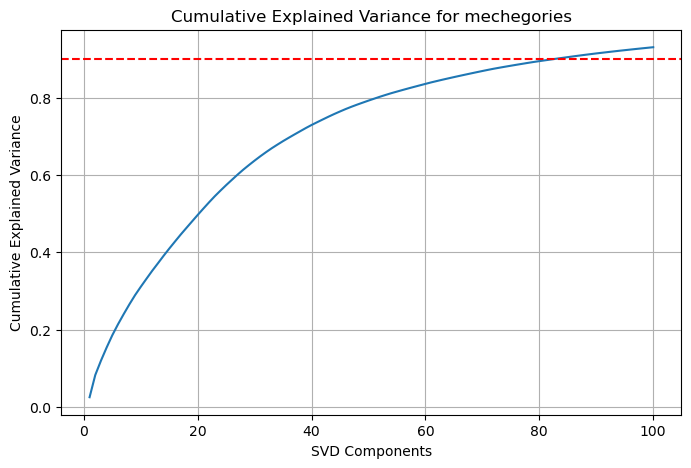

Optimal number of svd components: 83


In [19]:
# Determine optimal number of components (Cumulative Explained Variance)
svd_mech_full = TruncatedSVD(n_components=min(100, X_mech.shape[1]-1),random_state=42)

svd_mech_full.fit(X_mech)
explained_mech = np.cumsum(svd_mech_full.explained_variance_ratio_)

# Plot cumulative explained variance
plt.figure(figsize=(8,5))
plt.plot(range(1, len(explained_mech)+1), explained_mech)
plt.xlabel("SVD Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance for mechegories")
plt.axhline(y=0.90, color="r", linestyle="--")
plt.grid()
plt.show()

# Select n_components where 90% variance is retained
n_mech = np.argmax(explained_mech >= 0.90) + 1
print(f"Optimal number of svd components: {n_mech}")

In [20]:
# Apply SVD with optimal components
svd_mech = TruncatedSVD(n_components=n_mech, random_state=42)
mech_embeddings = svd_mech.fit_transform(X_mech)

mech_emb_cols = [f"svd_mech_{i}" for i in range(mech_embeddings.shape[1])]
mech_emb_df = pd.DataFrame(mech_embeddings, columns=mech_emb_cols)

Concatenate both embeddings

In [21]:
df = df.reset_index(drop=True)
cat_emb_df = cat_emb_df.reset_index(drop=True)
mech_emb_df = mech_emb_df.reset_index(drop=True)

emb_final = pd.concat([cat_emb_df, mech_emb_df], axis=1)

#### KMeans

After applying SVC we will group the columns in clusters

Optimal number of clusters from Knee Method: 9


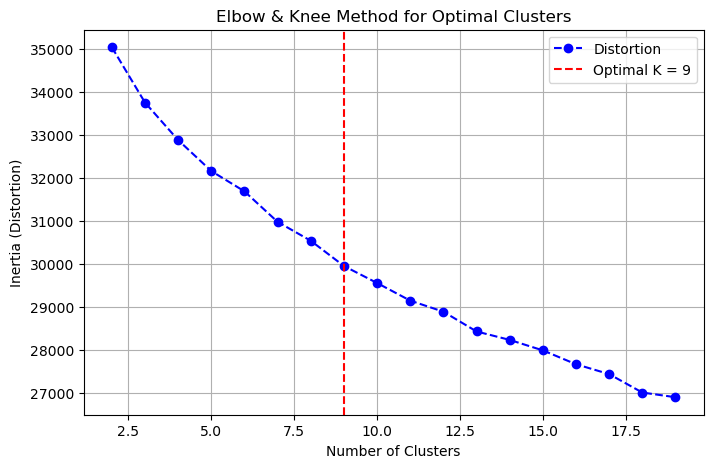

In [22]:
# Determine optimal number of clusters using the Elbow & Knee Method
distortions = []
K_range = range(2, 20)  # Test between 2 and 20 clusters

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(emb_final)
    distortions.append(kmeans.inertia_)

# Find the optimal k using the Knee Method
knee_locator = KneeLocator(K_range, distortions, curve="convex", direction="decreasing")
optimal_clusters = knee_locator.knee
print(f"Optimal number of clusters from Knee Method: {optimal_clusters}")

# Plot the elbow & knee method
plt.figure(figsize=(8, 5))
plt.plot(K_range, distortions, marker='o', linestyle='--', color='b', label="Distortion")
plt.axvline(x=optimal_clusters, color='r', linestyle='--', label=f"Optimal K = {optimal_clusters}")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia (Distortion)")
plt.title("Elbow & Knee Method for Optimal Clusters")
plt.legend()
plt.grid()
plt.show()

In [23]:
# Apply K-Means with optimal clusters
kmeans = KMeans(n_clusters=optimal_clusters, random_state=42, n_init=10)
df["game_cluster"] = kmeans.fit_predict(emb_final)
df = df.copy()

C:\Users\Aitor\AppData\Local\Temp\ipykernel_31036\1844503829.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["game_cluster"] = kmeans.fit_predict(emb_final)


In [24]:
# Silhouette score (-1 to 1)
silhouette_avg = silhouette_score(emb_final, df["game_cluster"])
print(f"Silhouette Score: {silhouette_avg:.2f}")

Silhouette Score: 0.08


In [25]:
df = pd.concat([df, cat_emb_df, mech_emb_df], axis=1)
print("Column headers:", list(df))

Column headers: ['id', 'name', 'average_rating', 'yearpublished', 'minplayers', 'maxplayers', 'minage', 'averageweight', 'rank', 'cat_play', 'cat_abstract_strategy', 'cat_action_dexterity', 'cat_adventure', 'cat_age_of_reason', 'cat_american_civil_war', 'cat_american_indian_wars', 'cat_american_revolutionary_war', 'cat_american_west', 'cat_ancient', 'cat_animals', 'cat_arabian', 'cat_aviation_flight', 'cat_based', 'cat_bluffing', 'cat_book', 'cat_card_game', 'cat_children', 'cat_city_building', 'cat_civil_war', 'cat_civilization', 'cat_collectible_components', 'cat_comic_book_strip', 'cat_deduction', 'cat_dice', 'cat_economic', 'cat_educational', 'cat_electronic', 'cat_environmental', 'cat_expansion_for_base', 'cat_exploration', 'cat_fan_expansion', 'cat_fantasy', 'cat_farming', 'cat_fighting', 'cat_game', 'cat_game_system', 'cat_horror', 'cat_humor', 'cat_industry_manufacturing', 'cat_korean_war', 'cat_mafia', 'cat_math', 'cat_mature_adult', 'cat_maze', 'cat_medical', 'cat_medieval', 

### 2D Visualization

To show the choosing of the 7 clusters in a visual way

In [26]:
svd_viz = TruncatedSVD(n_components=2, random_state=42)
svd_2d = svd_viz.fit_transform(emb_final)

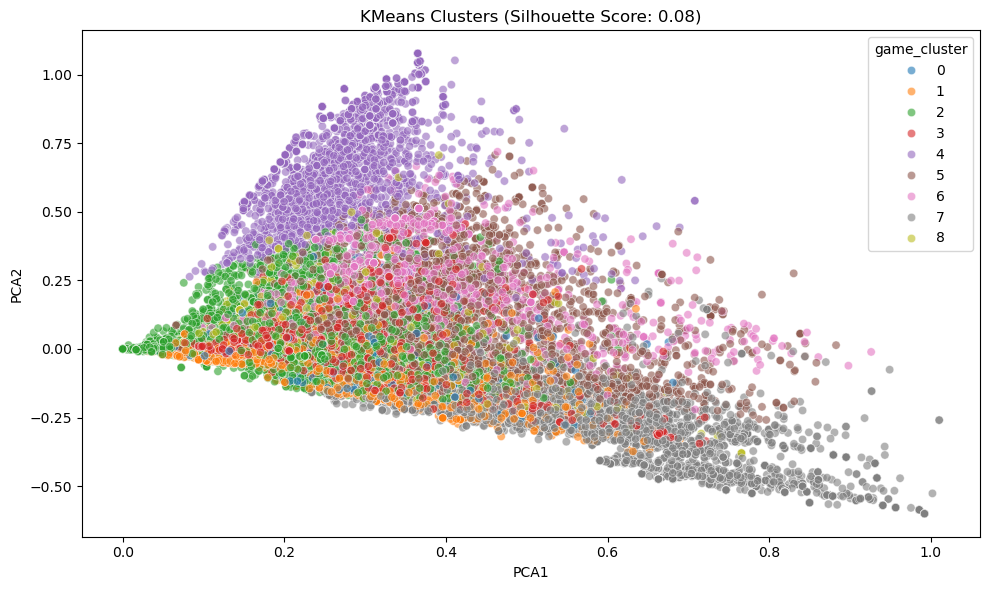

In [27]:
# Visualize clusters using PCA-reduced 2D space
plt.figure(figsize=(10,6))

sns.scatterplot(x=svd_2d[:,0],y=svd_2d[:,1],hue=df["game_cluster"],palette="tab10",alpha=0.6)

plt.title(f"KMeans Clusters (Silhouette Score: {silhouette_avg:.2f})")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.tight_layout()
plt.show()

Check some of the games that are in each cluster

In [28]:
for cluster in df["game_cluster"].unique():
    
    print("\nCLUSTER", cluster)
    
    print(
        df[df["game_cluster"] == cluster]
        .sort_values("average_rating", ascending=False)
        [["name","average_rating"]]
        .head(5)
    )


CLUSTER 2
                                                    name  average_rating
12284                                Lost in the Shuffle            9.17
1420   System Gateway (fan expansion for Android: Net...            9.10
7449                        AFU: Armed Forces of Ukraine            9.06
4150                      Company of Heroes: 2nd Edition            8.85
14946                                        Which Side?            8.77

CLUSTER 5
                                           name  average_rating
18726            War Titans: Invaders Must Die!            9.21
12184                                    Cysmic            9.03
414             Arydia: The Paths We Dare Tread            9.03
7639   Rogue Angels: Legacy of the Burning Suns            9.01
12671                        Eldfall Chronicles            9.00

CLUSTER 4
                                                    name  average_rating
6587          On to Richmond II: The Union Strikes South            9.13

Drop the now unused columns

In [29]:
# Since we did TruncatedSVD, we aren't going to use TF-IDF columns
tfidf_cols = [c for c in df.columns if c.startswith("cat_") or c.startswith("mech_")]
df = df.drop(columns=tfidf_cols)

print("Column headers:", list(df))

Column headers: ['id', 'name', 'average_rating', 'yearpublished', 'minplayers', 'maxplayers', 'minage', 'averageweight', 'rank', 'log_users_rated', 'log_owned', 'log_wishing', 'playtime_mean', 'game_cluster', 'svd_cat_0', 'svd_cat_1', 'svd_cat_2', 'svd_cat_3', 'svd_cat_4', 'svd_cat_5', 'svd_cat_6', 'svd_cat_7', 'svd_cat_8', 'svd_cat_9', 'svd_cat_10', 'svd_cat_11', 'svd_cat_12', 'svd_cat_13', 'svd_cat_14', 'svd_cat_15', 'svd_cat_16', 'svd_cat_17', 'svd_cat_18', 'svd_cat_19', 'svd_cat_20', 'svd_cat_21', 'svd_cat_22', 'svd_cat_23', 'svd_cat_24', 'svd_cat_25', 'svd_cat_26', 'svd_cat_27', 'svd_cat_28', 'svd_cat_29', 'svd_cat_30', 'svd_cat_31', 'svd_cat_32', 'svd_cat_33', 'svd_cat_34', 'svd_cat_35', 'svd_cat_36', 'svd_cat_37', 'svd_cat_38', 'svd_cat_39', 'svd_cat_40', 'svd_cat_41', 'svd_cat_42', 'svd_cat_43', 'svd_cat_44', 'svd_cat_45', 'svd_cat_46', 'svd_cat_47', 'svd_cat_48', 'svd_cat_49', 'svd_cat_50', 'svd_cat_51', 'svd_cat_52', 'svd_cat_53', 'svd_mech_0', 'svd_mech_1', 'svd_mech_2', 'sv

#### Save database after feature engineering

In [30]:
df.to_csv("../data/processed/boardgames_features.csv", index=False)